In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("df_final.csv", index_col="date", parse_dates=True)

print(df.shape)
print(df.head(3))

(52440, 15)
                     price_eur_mwh  temperature  wind_speed  radiation  \
date                                                                     
2019-01-08 00:00:00          17.94          4.2        22.9        0.0   
2019-01-08 01:00:00          20.91          4.5        23.2        0.0   
2019-01-08 02:00:00           7.78          4.8        22.2        0.0   

                     precipitation  wind_power  solar_proxy  heating_degree  \
date                                                                          
2019-01-08 00:00:00            0.6   12008.989          0.0            13.8   
2019-01-08 01:00:00            0.5   12487.168          0.0            13.5   
2019-01-08 02:00:00            0.6   10941.048          0.0            13.2   

                     cooling_degree  hour  weekday  month  is_weekend  \
date                                                                    
2019-01-08 00:00:00             0.0     0        1      1           0   
20

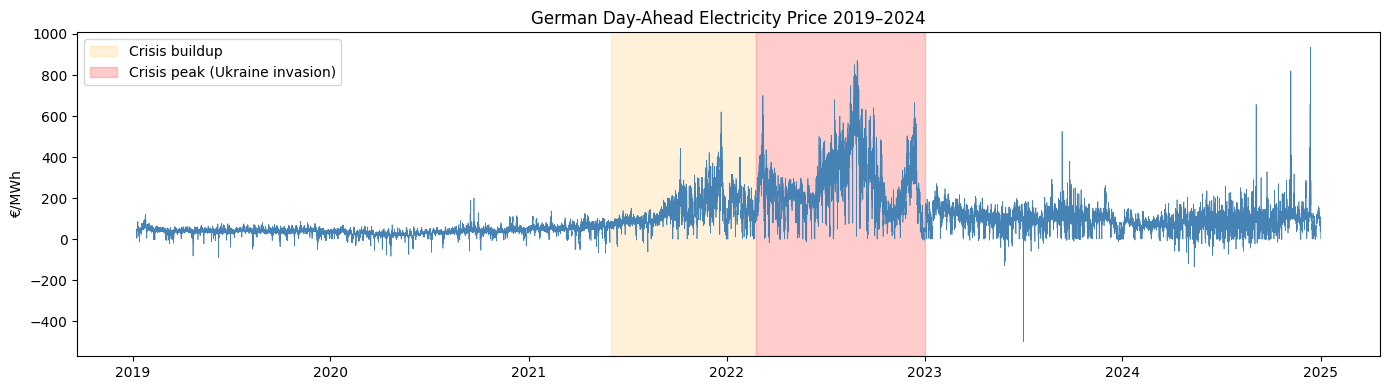

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df["price_eur_mwh"], linewidth=0.5, color="steelblue")

# Crisis buildup — prices start rising after Russia reduces gas supply
plt.axvspan("2021-06-01", "2022-02-23", alpha=0.15, color="orange", label="Crisis buildup")

# Crisis peak — Russia invades Ukraine, prices hit record >€200/MWh
plt.axvspan("2022-02-24", "2023-01-01", alpha=0.2, color="red", label="Crisis peak (Ukraine invasion)")

plt.title("German Day-Ahead Electricity Price 2019–2024")
plt.ylabel("€/MWh")
plt.legend()
plt.tight_layout()
plt.show()

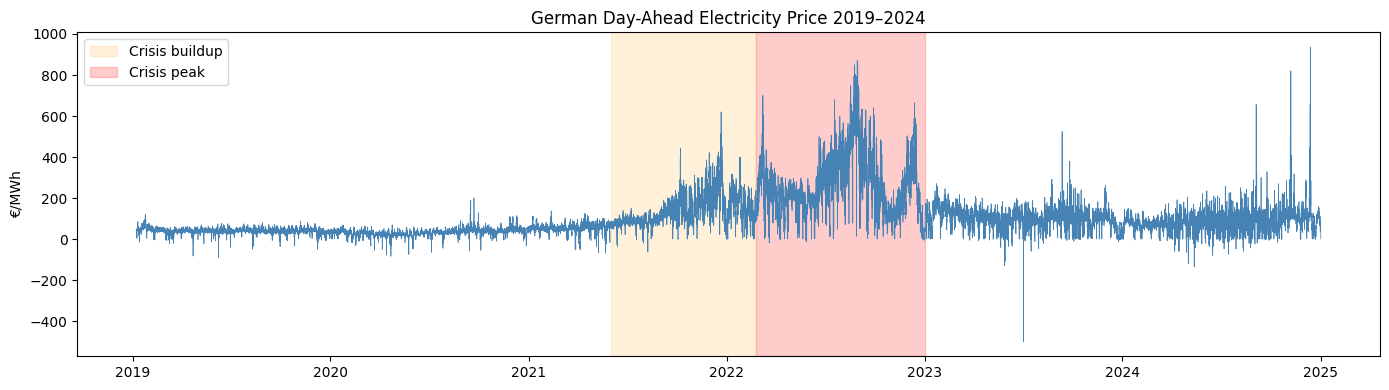

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df["price_eur_mwh"], linewidth=0.5, color="steelblue")
plt.axvspan("2021-06-01", "2022-02-23", alpha=0.15, color="orange", label="Crisis buildup")
plt.axvspan("2022-02-24", "2023-01-01", alpha=0.2, color="red", label="Crisis peak")
plt.title("German Day-Ahead Electricity Price 2019–2024")
plt.ylabel("€/MWh")
plt.legend()
plt.tight_layout()
plt.show()

### Price distribution

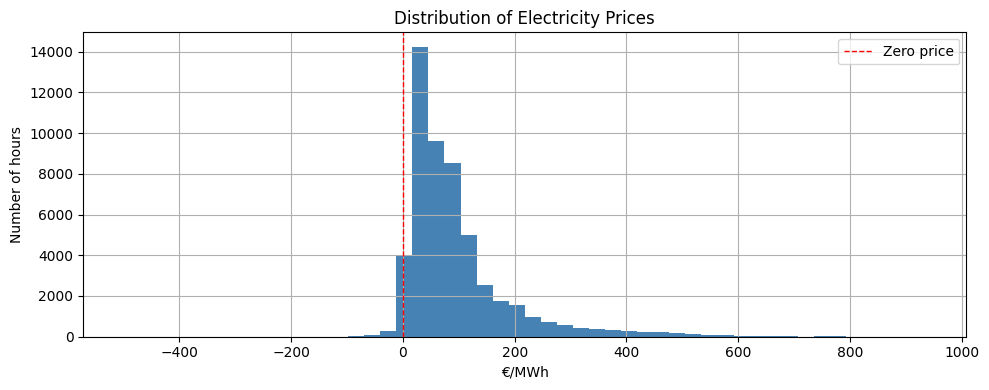

Negative price hours: 1452 (2.8% of all hours)


In [4]:
plt.figure(figsize=(10, 4))
df["price_eur_mwh"].hist(bins=50, color="steelblue", edgecolor="none")
plt.axvline(0, color="red", linewidth=1, linestyle="--", label="Zero price")
plt.title("Distribution of Electricity Prices")
plt.xlabel("€/MWh")
plt.ylabel("Number of hours")
plt.legend()
plt.tight_layout()
plt.show()

negative = (df["price_eur_mwh"] < 0).sum()
print(f"Negative price hours: {negative} ({100*negative/len(df):.1f}% of all hours)")

### Average price by hour

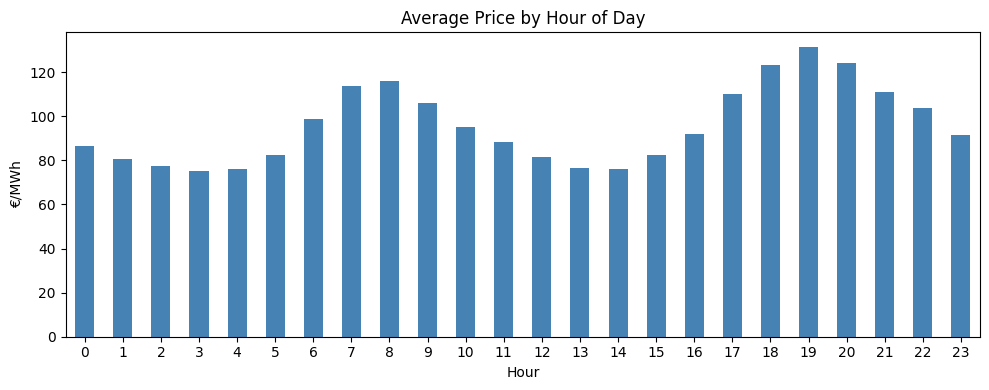

In [5]:
plt.figure(figsize=(10, 4))
df.groupby("hour")["price_eur_mwh"].mean().plot(kind="bar", color="steelblue", edgecolor="none")
plt.title("Average Price by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("€/MWh")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

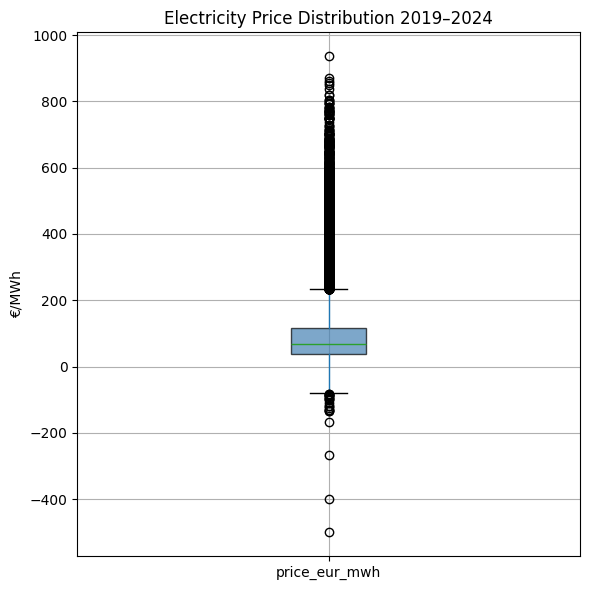

In [6]:
plt.figure(figsize=(6, 6))
df.boxplot(column="price_eur_mwh",
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.7))
plt.title("Electricity Price Distribution 2019–2024")
plt.ylabel("€/MWh")
plt.tight_layout()
plt.show()

In [7]:
df["year"] = df.index.year

<Figure size 1000x500 with 0 Axes>

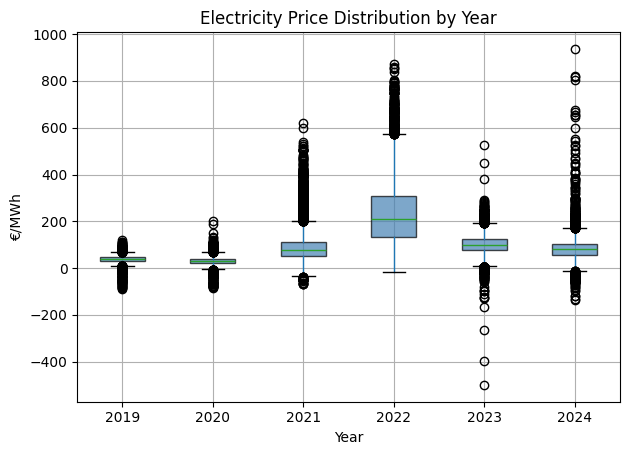

In [8]:
plt.figure(figsize=(10, 5))
df.boxplot(column="price_eur_mwh", by="year", 
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.7))
plt.suptitle("")
plt.title("Electricity Price Distribution by Year")
plt.xlabel("Year")
plt.ylabel("€/MWh")
plt.tight_layout()
plt.show()

### 2019–2020 - Normal market
Prices tight and low, median around €35–40/MWh. Small spread, few outliers.
This is what a healthy competitive electricity market looks like.

### 2020 - COVID effect
Slightly lower than 2019 — lockdowns reduced industrial demand, pushing prices down.

### 2021 - Crisis begins
Box starts rising and widening significantly. Russia begins reducing gas flows to Europe,
prices become more volatile and unpredictable. Outliers appear above €400/MWh.

### 2022 - Crisis peak
The box explodes. Median jumps to ~€200/MWh — roughly 5x normal levels.
Extreme outliers reach €800+/MWh. This is the direct effect of the Ukraine invasion
and gas supply cuts. Largest spread of any year — market was highly uncertain.

### 2023 - Recovery begins
Box shrinks back dramatically. Median returns to ~€100/MWh.
Notable: **negative price outliers appear**, going as low as -€400/MWh.
Germany rapidly expanded renewables to replace gas, causing frequent oversupply episodes
where supply exceeded demand and prices turned negative.

### 2024 - New normal
Similar to 2023 but slightly lower median. Market stabilizing but prices remain
above pre-crisis levels. Negative price outliers persist — more renewables means
more frequent oversupply events.

---

### Key takeaway
> The 2022 crisis created a price regime completely outside the historical range.
> Weather data alone cannot predict prices during geopolitical shocks —
> the absolute price level during the crisis was driven by gas scarcity, not weather.
> This is the fundamental limitation of a weather-only model and a natural
> direction for future work: adding gas price as a feature.

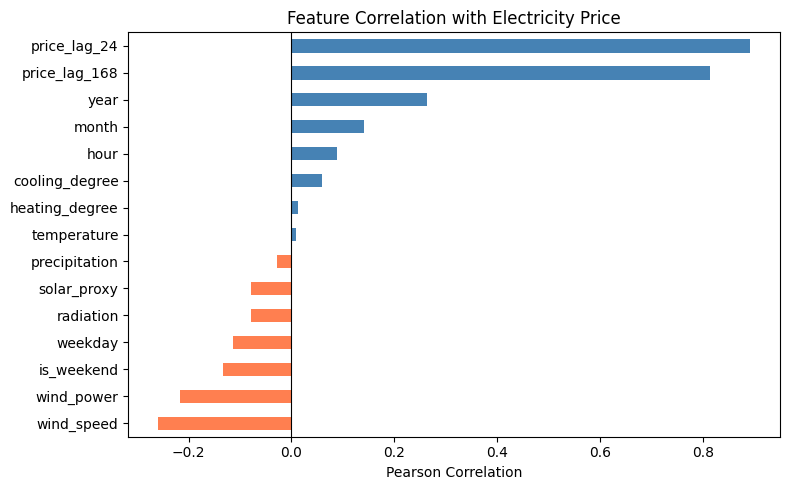

In [9]:
plt.figure(figsize=(8, 5))
corr = df.corr()["price_eur_mwh"].drop("price_eur_mwh").sort_values()
colors = ["coral" if c < 0 else "steelblue" for c in corr]
corr.plot(kind="barh", color=colors, edgecolor="none")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Electricity Price")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

In [10]:
# Drop year — it captures crisis trend, not a real weather/time predictor
df = df.drop(columns=["year"])

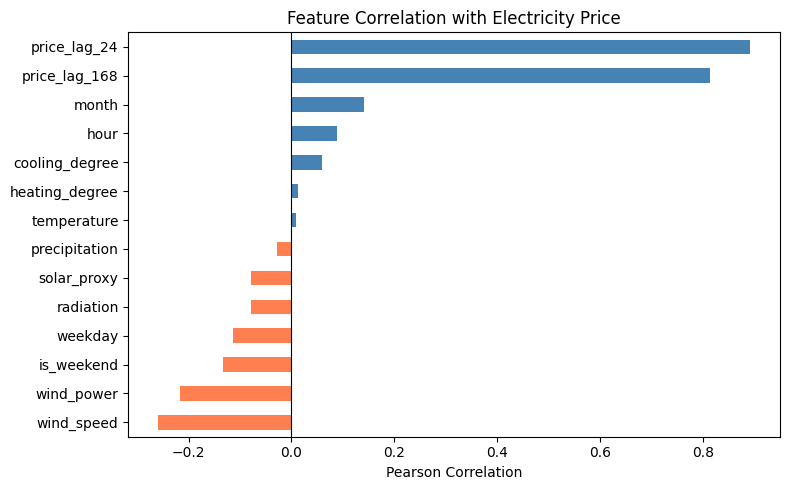

In [11]:
plt.figure(figsize=(8, 5))
corr = df.corr()["price_eur_mwh"].drop("price_eur_mwh").sort_values()
colors = ["coral" if c < 0 else "steelblue" for c in corr]
corr.plot(kind="barh", color=colors, edgecolor="none")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Electricity Price")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

Not dropping month, cause it correlates with price because of genuine recurring seasonal patterns that repeat every year:

January is cold every year → heating demand → higher price

July is hot every year → cooling demand → higher price

Spring and autumn are mild every year → lower demand → lower price

### Heatmap of avg price by hour and month 

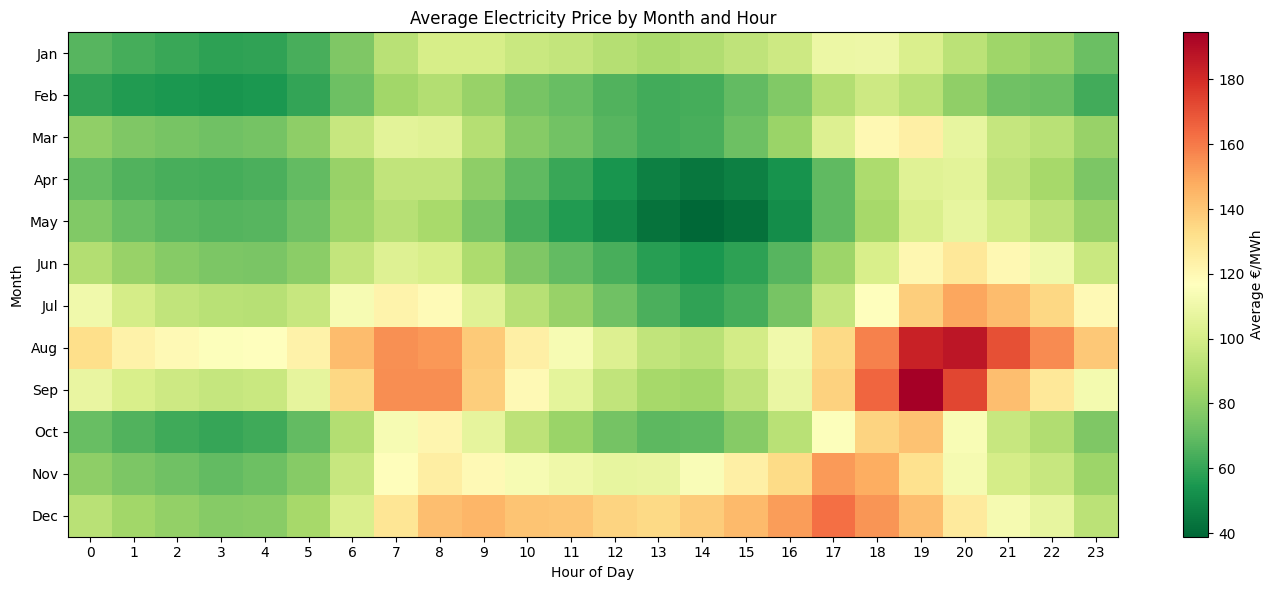

In [12]:
import matplotlib.pyplot as plt
import numpy as np

pivot = df.groupby(["month", "hour"])["price_eur_mwh"].mean().unstack()

plt.figure(figsize=(14, 6))
plt.imshow(pivot, aspect="auto", cmap="RdYlGn_r")
plt.colorbar(label="Average €/MWh")
plt.title("Average Electricity Price by Month and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Month")
plt.xticks(range(24), range(24))
plt.yticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

#### The dark green block (Apr–Jun, hours 10–15) — cheapest electricity
Spring midday is the cheapest time of year. Why? Long sunny days mean maximum solar generation, mild temperatures mean low heating/cooling demand, and spring is often windy in Germany. All three factors push price down simultaneously.

#### The red/orange block (Aug–Sep, hours 18–20) — most expensive
Late summer evenings are the most expensive. Why? Solar panels stop generating after sunset, but people come home from work and turn on appliances, cooking, heating water. Demand peaks exactly when solar disappears. August and September are also historically when gas storage was lowest during the crisis years, which amplifies the effect.

#### The daily pattern visible in every month

Hours 0–5 — cheap everywhere, everyone is sleeping
Hours 6–9 — prices rise as industry and offices start
Hours 10–15 — drops in spring/summer due to solar
Hours 17–21 — evening peak, solar gone, demand high
Hours 22–23 — drops again as activity winds down

### Weekend vs Weekday

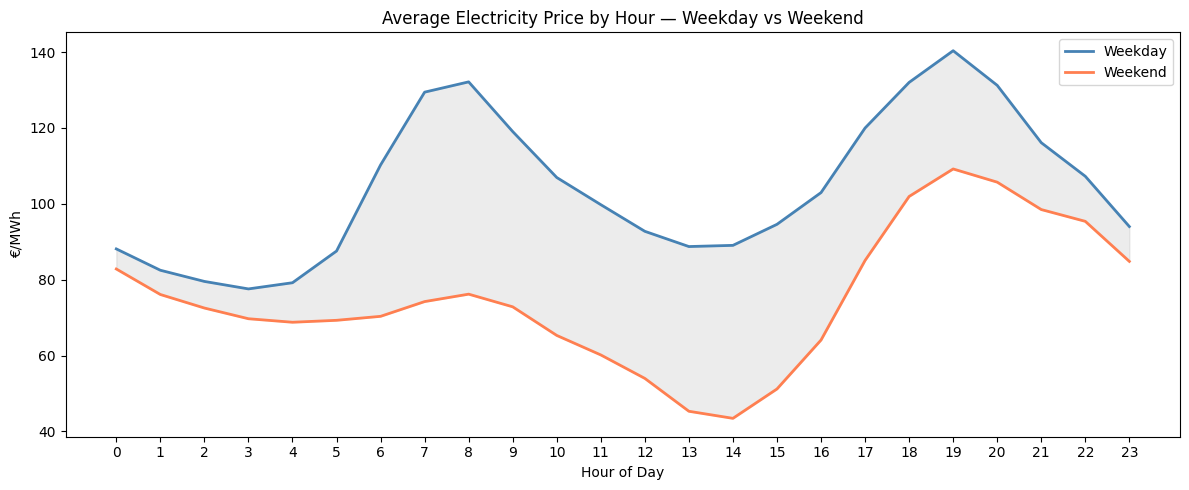

Average weekday price: €104.2/MWh
Average weekend price: €74.9/MWh
Average difference: €29.3/MWh


In [13]:
plt.figure(figsize=(12, 5))

pivot_weekday = df[df["is_weekend"]==0].groupby("hour")["price_eur_mwh"].mean()
pivot_weekend = df[df["is_weekend"]==1].groupby("hour")["price_eur_mwh"].mean()

plt.plot(pivot_weekday, color="steelblue", linewidth=2, label="Weekday")
plt.plot(pivot_weekend, color="coral", linewidth=2, label="Weekend")
plt.fill_between(pivot_weekday.index, pivot_weekday, pivot_weekend, alpha=0.15, color="gray")
plt.title("Average Electricity Price by Hour — Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("€/MWh")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

diff = (pivot_weekday - pivot_weekend).mean()
print(f"Average weekday price: €{pivot_weekday.mean():.1f}/MWh")
print(f"Average weekend price: €{pivot_weekend.mean():.1f}/MWh")
print(f"Average difference: €{diff:.1f}/MWh")

The shaded area between the lines shows exactly when and how much weekdays are more expensive than weekends. The morning peak (7–9am) is much stronger on weekdays when industry starts up.